17
16


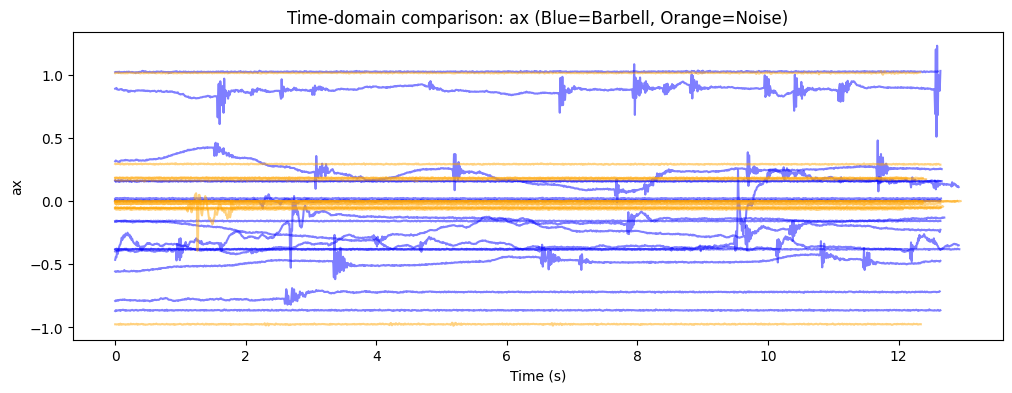

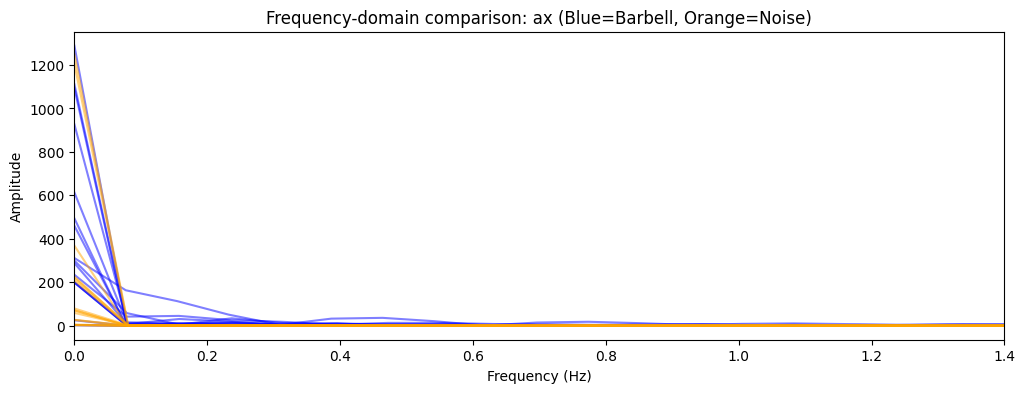

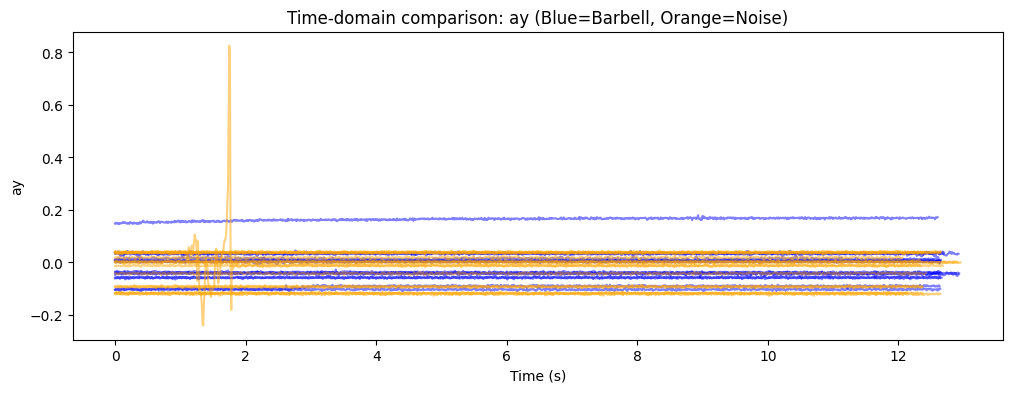

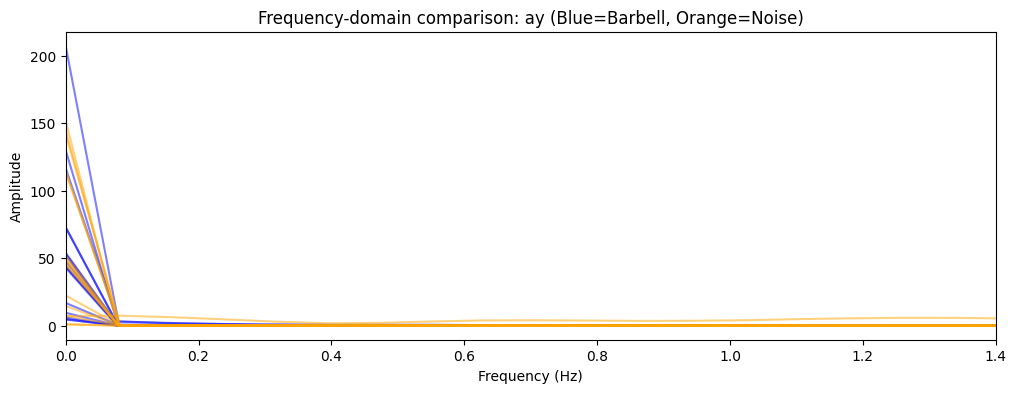

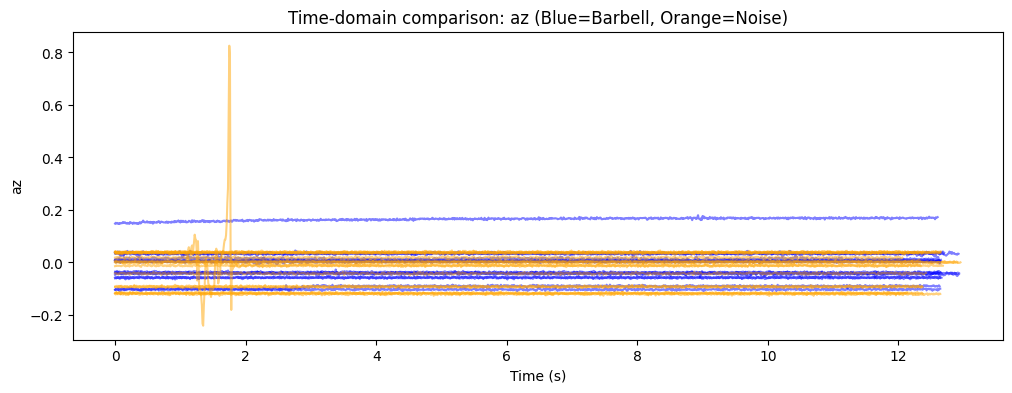

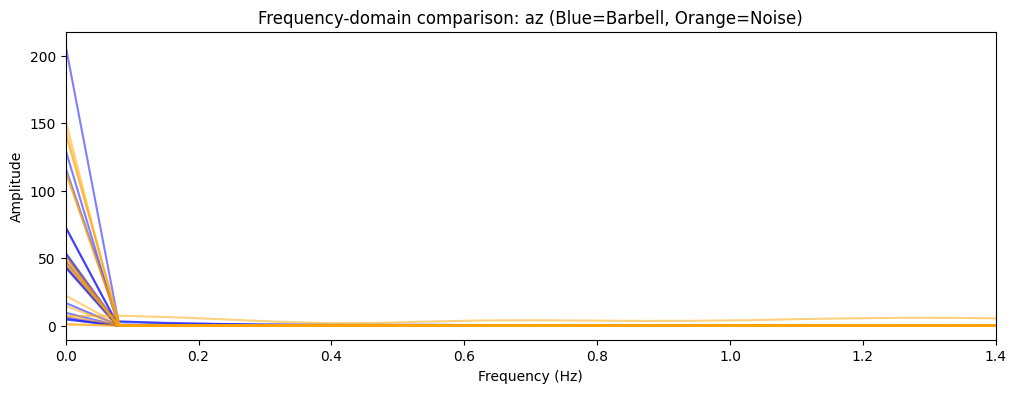

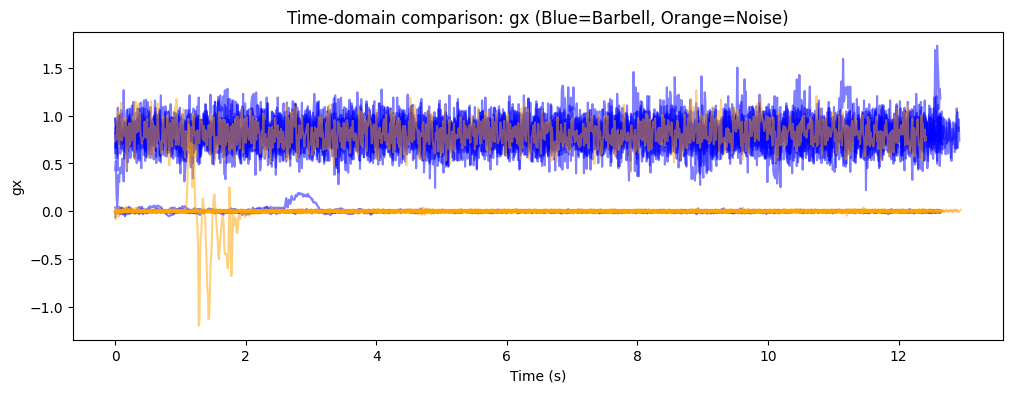

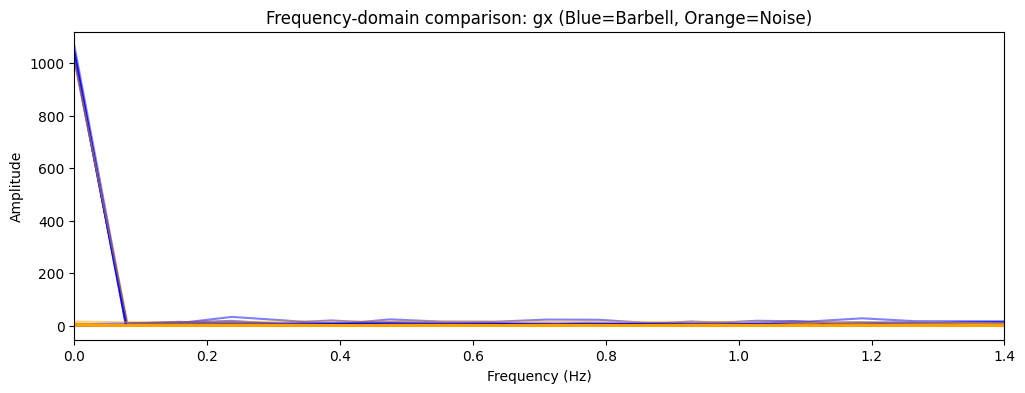

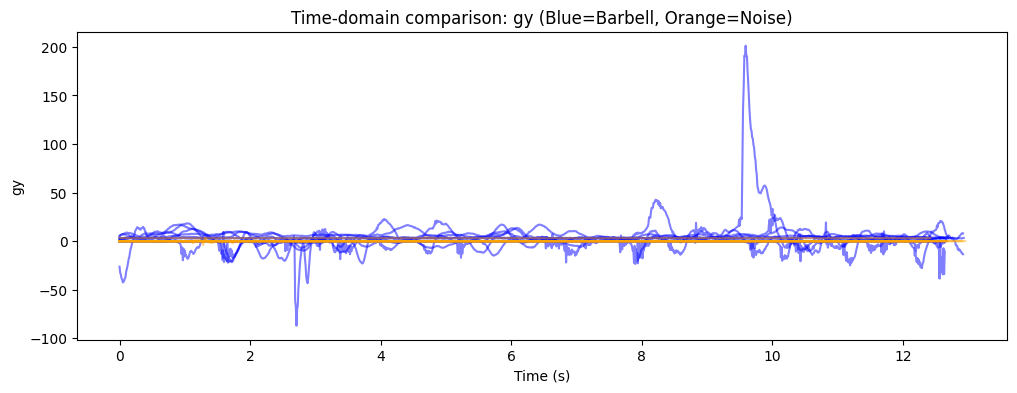

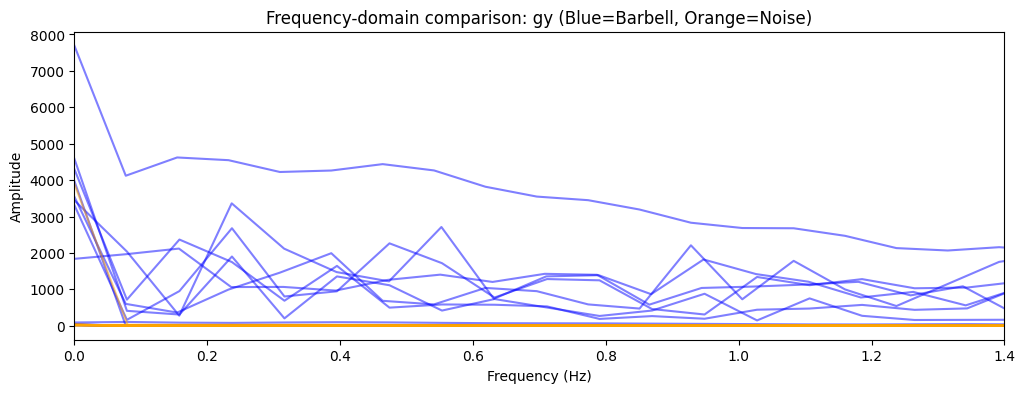

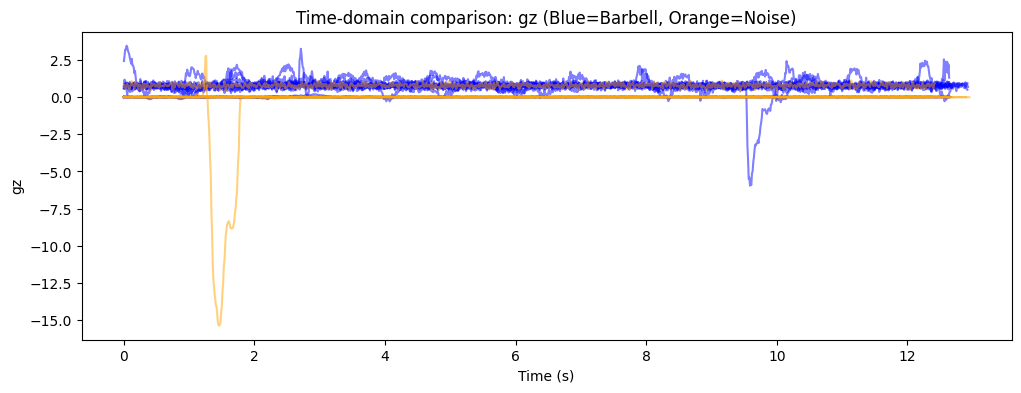

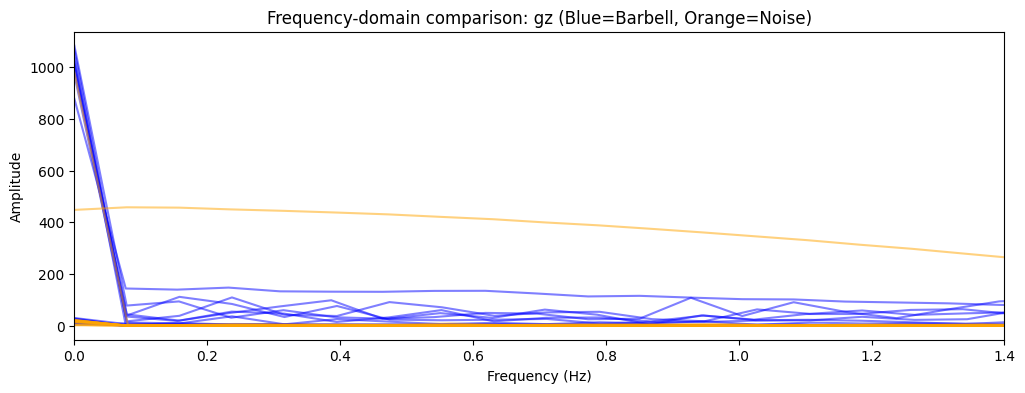

In [3]:
import matplotlib.pyplot as plt
from thinkdsp import Wave
import sqlite3
import pandas as pd

# -------------------------
# Parameters
# -------------------------
db_path = "sensor_database.db"
fs = 100  # sensor sampling rate
noise_type = "DEVICE_STATIONARY"  # the "noise" comparison
barbell_type = "BARBELL_STATIONARY"  # the main barbell sessions
axes = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

# -------------------------
# Helper function to fetch all sessions for a noise type
# -------------------------
def get_all_sessions_data(db_path, noise_type):
    conn = sqlite3.connect(db_path)
    
    # All session IDs for the noise type
    session_ids = pd.read_sql(
        f"SELECT sessionId FROM session WHERE noise = '{noise_type}' ORDER BY sessionId ASC;",
        conn
    )['sessionId'].tolist()
    
    # Fetch rawdata for each session
    sessions_data = {}
    for sid in session_ids:
        df = pd.read_sql(
            f"SELECT ax, ay, az, gx, gy, gz FROM rawdata WHERE sessionId = {sid};",
            conn
        )
        sessions_data[sid] = df
    
    conn.close()
    return sessions_data

# -------------------------
# Load all sessions
# -------------------------
barbell_sessions = get_all_sessions_data(db_path, barbell_type)
print(len(barbell_sessions))
noise_sessions = get_all_sessions_data(db_path, noise_type)
print(len(noise_sessions))

# -------------------------
# Plotting
# -------------------------
for axis in axes:
    plt.figure(figsize=(12, 4))
    
    # Plot all barbell sessions in one color
    for sid, df in barbell_sessions.items():
        wave = Wave(df[axis].values, framerate=fs)
        plt.plot(wave.ts, wave.ys, color='blue', alpha=0.5)
    
    # Plot all noise sessions in another color
    for sid, df in noise_sessions.items():
        wave = Wave(df[axis].values, framerate=fs)
        plt.plot(wave.ts, wave.ys, color='orange', alpha=0.5)
    
    plt.xlabel('Time (s)')
    plt.ylabel(axis)
    plt.title(f'Time-domain comparison: {axis} (Blue=Barbell, Orange=Noise)')
    plt.show()

    # Frequency-domain plot
    plt.figure(figsize=(12, 4))
    
    for sid, df in barbell_sessions.items():
        wave = Wave(df[axis].values, framerate=fs)
        spectrum = wave.make_spectrum()
        spectrum.plot(color='blue', alpha=0.5)
    
    for sid, df in noise_sessions.items():
        wave = Wave(df[axis].values, framerate=fs)
        spectrum = wave.make_spectrum()
        spectrum.plot(color='orange', alpha=0.5)
    
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.xlim(0, 1.4)  # adjust to focus on frequencies of interest
    plt.title(f'Frequency-domain comparison: {axis} (Blue=Barbell, Orange=Noise)')
    plt.show()

